In [269]:
import torch
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [242]:
student_mat = pd.read_csv("../datasets/student-mat.csv", sep = ";")
student_por = pd.read_csv("../datasets/student-por.csv", sep = ";")

In [243]:
df = pd.concat([student_mat, student_por], ignore_index = True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1044 entries, 0 to 1043
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      1044 non-null   object
 1   sex         1044 non-null   object
 2   age         1044 non-null   int64 
 3   address     1044 non-null   object
 4   famsize     1044 non-null   object
 5   Pstatus     1044 non-null   object
 6   Medu        1044 non-null   int64 
 7   Fedu        1044 non-null   int64 
 8   Mjob        1044 non-null   object
 9   Fjob        1044 non-null   object
 10  reason      1044 non-null   object
 11  guardian    1044 non-null   object
 12  traveltime  1044 non-null   int64 
 13  studytime   1044 non-null   int64 
 14  failures    1044 non-null   int64 
 15  schoolsup   1044 non-null   object
 16  famsup      1044 non-null   object
 17  paid        1044 non-null   object
 18  activities  1044 non-null   object
 19  nursery     1044 non-null   object
 20  higher  

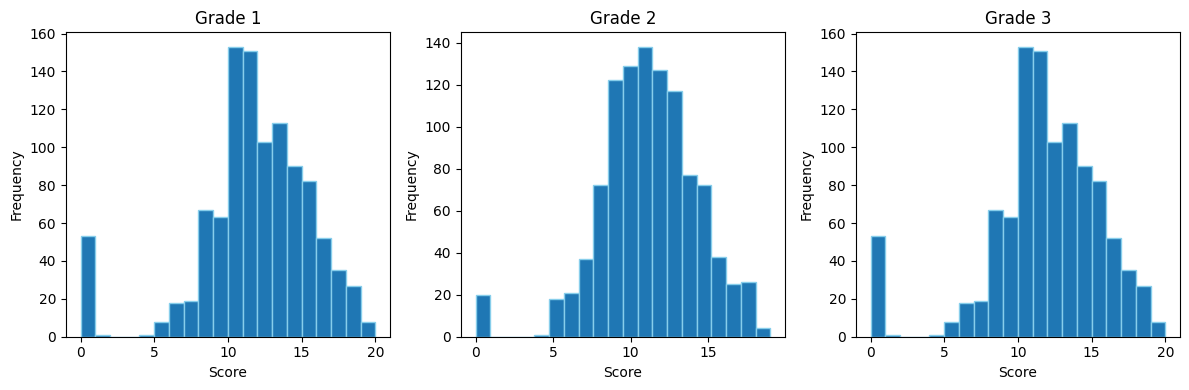

In [244]:
plt.figure(figsize=(12, 4))

plt.subplot(1,3,1)
plt.title("Grade 1")
plt.hist(df["G3"], bins = 20, label = "Final Grade", edgecolor = "skyblue")
plt.xlabel("Score")
plt.ylabel("Frequency")

plt.subplot(1, 3, 2)
plt.title("Grade 2")
plt.hist(df["G2"], bins = 20, label = "Final Grade", edgecolor = "skyblue")
plt.xlabel("Score")
plt.ylabel("Frequency")

plt.subplot(1, 3, 3)
plt.title("Grade 3")
plt.hist(df["G3"], bins = 20, label = "Final Grade", edgecolor = "skyblue")
plt.xlabel("Score")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

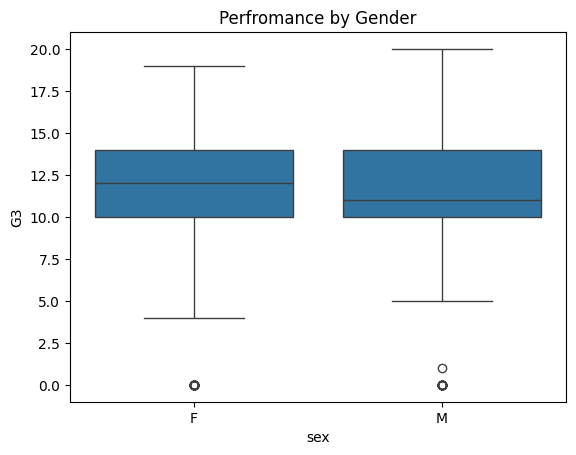

In [245]:
sns.boxplot(x = "sex", y = "G3", data = df)
plt.title("Perfromance by Gender")
plt.show()

In [246]:
df = df.drop(["school", "Pstatus", "reason", "guardian", "G1", "G2"], axis = 1)

In [247]:
X = df.drop(columns = ["G3"])
y = df["G3"]

In [248]:
X_encoded = pd.get_dummies(X, drop_first = True, dtype = int)
X_encoded.head()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,...,Fjob_services,Fjob_teacher,schoolsup_yes,famsup_yes,paid_yes,activities_yes,nursery_yes,higher_yes,internet_yes,romantic_yes
0,18,4,4,2,2,0,4,3,4,1,...,0,1,1,0,0,0,1,1,0,0
1,17,1,1,1,2,0,5,3,3,1,...,0,0,0,1,0,0,0,1,1,0
2,15,1,1,1,2,3,4,3,2,2,...,0,0,1,0,1,0,1,1,1,0
3,15,4,2,1,3,0,3,2,2,1,...,1,0,0,1,1,1,1,1,1,1
4,16,3,3,1,2,0,4,3,2,1,...,0,0,0,1,1,0,1,1,0,0


In [249]:
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size = 0.2, random_state = 42)
X_train.shape, X_test.shape, y_train.shape

((835, 32), (209, 32), (835,))

In [259]:
y_train = y_train.to_numpy()
y_test = y_test.to_numpy()

In [250]:
y_train[:5].info()

<class 'pandas.core.series.Series'>
Index: 5 entries, 531 to 930
Series name: G3
Non-Null Count  Dtype
--------------  -----
5 non-null      int64
dtypes: int64(1)
memory usage: 80.0 bytes


In [251]:
X_train[:5]

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,...,Fjob_services,Fjob_teacher,schoolsup_yes,famsup_yes,paid_yes,activities_yes,nursery_yes,higher_yes,internet_yes,romantic_yes
531,16,2,1,4,1,0,3,2,1,1,...,0,0,0,0,0,0,1,1,0,0
256,17,4,2,1,4,0,4,2,3,1,...,1,0,0,1,1,1,1,1,1,0
350,19,1,1,3,2,3,5,4,4,3,...,1,0,0,0,0,0,1,1,1,0
60,16,4,4,1,2,0,2,4,4,2,...,0,1,0,1,0,1,1,1,0,0
930,15,1,2,3,2,0,5,5,5,1,...,1,0,0,1,0,1,1,1,0,0


In [252]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [253]:
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns = X_train.columns)

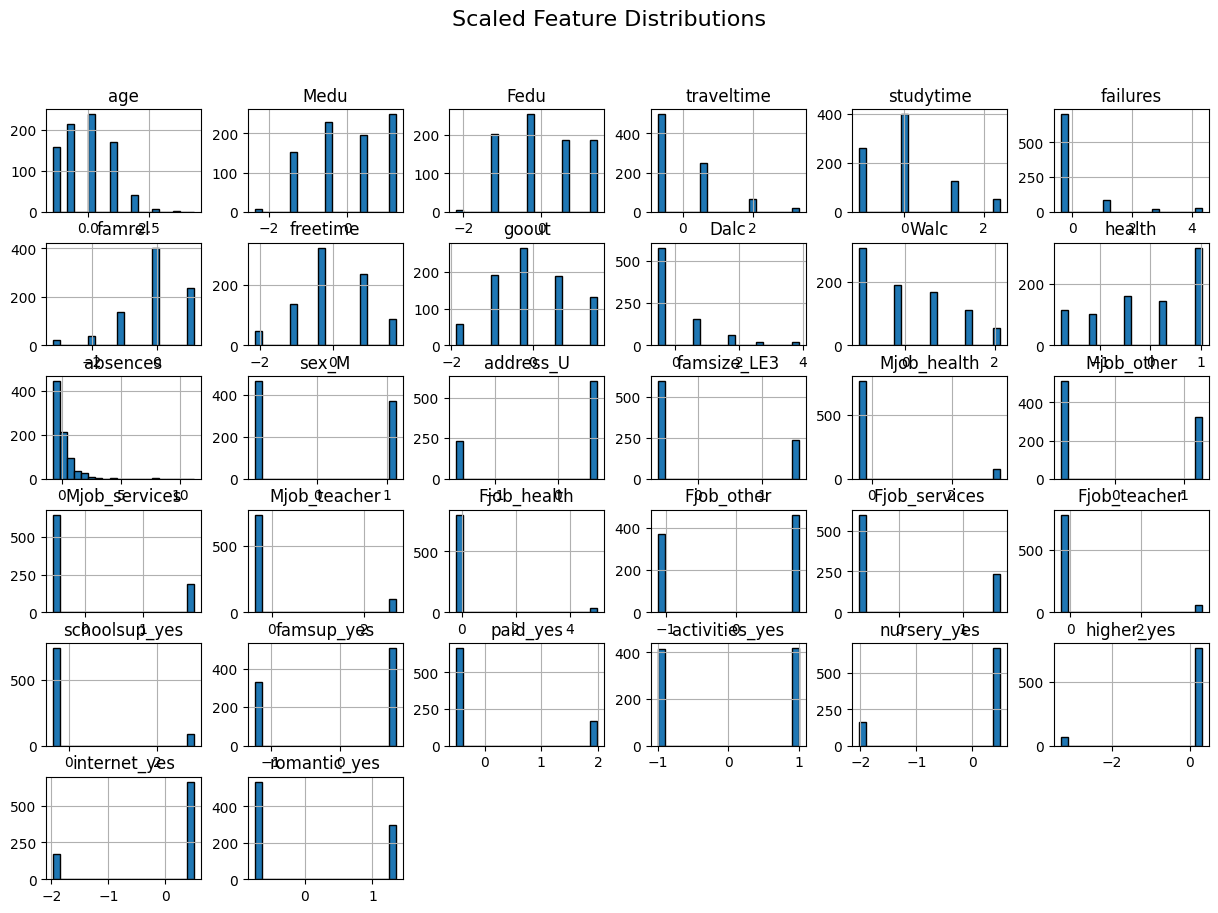

In [254]:
X_train_scaled_df.hist(figsize=(15, 10), bins=20, edgecolor='black')
plt.suptitle("Scaled Feature Distributions", fontsize=16)
plt.show()

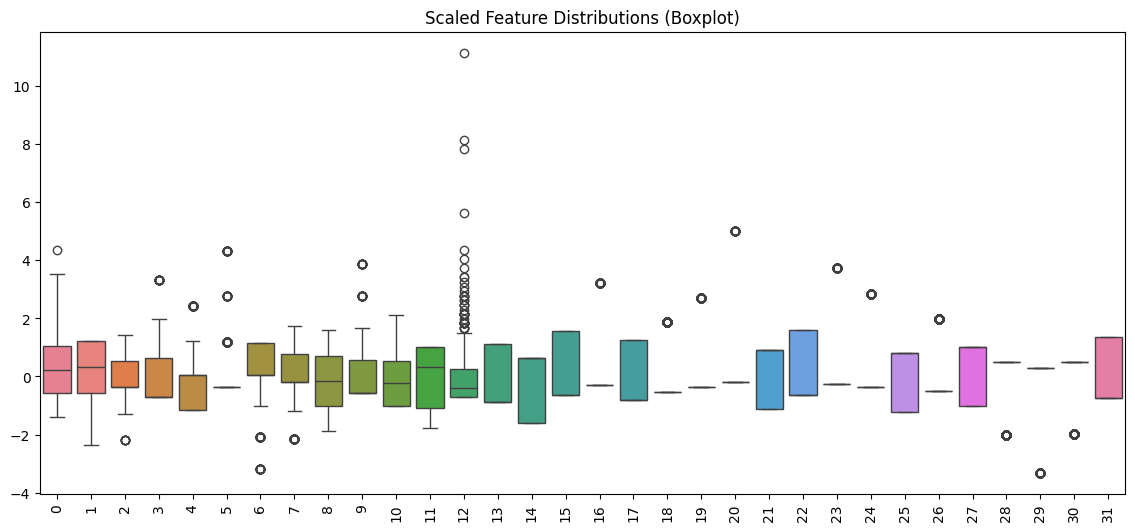

In [255]:
plt.figure(figsize=(14,6))
sns.boxplot(data=X_train_scaled)
plt.xticks(rotation=90)
plt.title("Scaled Feature Distributions (Boxplot)")
plt.show()

In [256]:
pca = PCA(n_components = 2)
X_train_scaled_2d = pca.fit_transform(X_train_scaled)

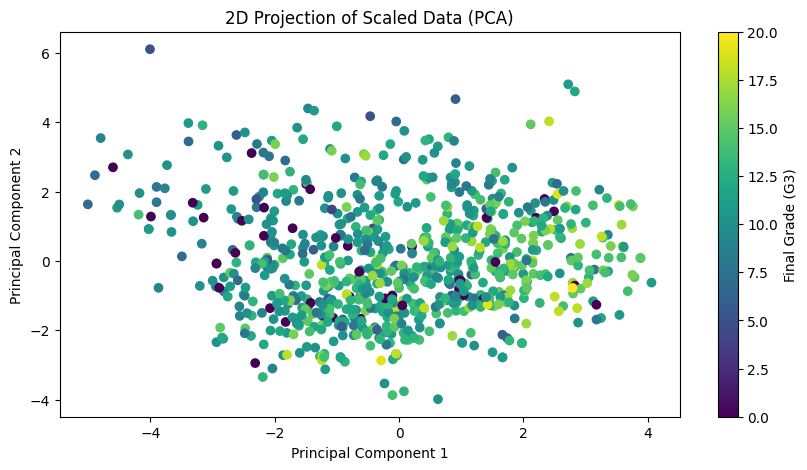

In [257]:
plt.figure(figsize=(10, 5))
plt.scatter(X_train_scaled_2d[:, 0], X_train_scaled_2d[:, 1], c=y_train, cmap="viridis")
plt.title("2D Projection of Scaled Data (PCA)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(label="Final Grade (G3)")
plt.show()

In [260]:
X_train, X_test = torch.tensor(X_train_scaled, dtype = torch.float), torch.tensor(X_test_scaled, dtype = torch.float)
y_train, y_test = torch.tensor(y_train, dtype = torch.float), torch.tensor(y_test, dtype = torch.float)

X_train, X_test = X_train.to(device), X_test.to(device)
y_train, y_test = y_train.to(device), y_test.to(device)

In [261]:
X_train.shape, y_train.shape, y_train.unique()

(torch.Size([835, 32]),
 torch.Size([835]),
 tensor([ 0.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12., 13., 14., 15., 16.,
         17., 18., 19., 20.], device='mps:0'))

In [262]:
len(y_train.unique()), len(y_test.unique())

(18, 17)

In [263]:
device = "mps" if torch.mps.is_available() else "cpu"
device

'mps'

In [277]:
class StudentPerformance(torch.nn.Module):
    def __init__(self, in_features: int = None, out_features: int = None, hidden_units: int = 16):
        super(StudentPerformance, self).__init__()
        self.in_features: int = in_features or X_train.shape[1]
        self.out_features: int = out_features
        self.hidden_units: int = hidden_units

        self.squencelayer = torch.nn.Sequential(
            torch.nn.Linear(in_features = self.in_features,
                           out_features = self.hidden_units),
            torch.nn.ReLU(),
            torch.nn.Linear(in_features = self.hidden_units,
                           out_features = self.hidden_units),
            torch.nn.ReLU(),
            torch.nn.Linear(in_features = self.hidden_units,
                           out_features = self.out_features)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.squencelayer(x)

In [278]:
model = StudentPerformance(in_features = 32, out_features = 1).to(device)
model

StudentPerformance(
  (squencelayer): Sequential(
    (0): Linear(in_features=32, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=1, bias=True)
  )
)

In [279]:
model.eval()
with torch.inference_mode():
    y_pred = model(X_test)

y_pred[:4].squeeze(), y_test[:4]

(tensor([ 0.1007,  0.0674, -0.0239,  0.0165], device='mps:0'),
 tensor([11.,  8., 13., 11.], device='mps:0'))

In [280]:
y_pred.shape, y_test.shape

(torch.Size([209, 1]), torch.Size([209]))

In [281]:
loss_fn = torch.nn.L1Loss()
optimizer = torch.optim.Adam(params = model.parameters(), lr = 0.1)

In [282]:
epochs = 500
total_epochs = []
losses = []
test_losses = []

In [283]:
for epoch in range(epochs):
    model.train()

    y_pred = model(X_train).squeeze()
    #train_accuracy = accuracy_score(y_train.detach().cpu(), y_pred.detach().cpu())

    loss = loss_fn(y_pred, y_train)
    optimizer.zero_grad()

    loss.backward()
    optimizer.step()
    losses.append(loss.item())

    model.eval()
    with torch.inference_mode():
        y_test_pred = model(X_test).squeeze()
        #test_accuracy = accuracy_score(y_test.detach().cpu(), test_y_pred.detach().cpu())
        test_loss = loss_fn(y_test_pred, y_test)
        test_losses.append(test_loss.item())

    total_epochs.append(epoch)
    if epoch % (0.1 * epochs) == 0:
        print(f"Train Loss: {loss} | Test Loss: {test_loss}")
        #print(f"Train Accuracy: {train_accuracy} | Test Accuracy: {test_accuracy}\n")

Train Loss: 11.4110689163208 | Test Loss: 10.366025924682617
Train Loss: 1.8751420974731445 | Test Loss: 2.663177251815796
Train Loss: 1.6906697750091553 | Test Loss: 2.641522169113159
Train Loss: 1.5637034177780151 | Test Loss: 2.6398370265960693
Train Loss: 1.5340440273284912 | Test Loss: 2.641413450241089
Train Loss: 1.4346954822540283 | Test Loss: 2.691518783569336
Train Loss: 1.4616892337799072 | Test Loss: 2.667064666748047
Train Loss: 1.390415072441101 | Test Loss: 2.683518409729004
Train Loss: 1.389211893081665 | Test Loss: 2.714029312133789
Train Loss: 1.4007155895233154 | Test Loss: 2.718186378479004


In [288]:
model.eval()
with torch.inference_mode():
    y_pred = model(X_test)

y_pred[:4].squeeze(), y_test[:4]

(tensor([15.6169,  8.7151, 14.3731, 12.9810], device='mps:0'),
 tensor([11.,  8., 13., 11.], device='mps:0'))

In [289]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_true = y_test.cpu().numpy()
y_pred_np = y_pred.detach().cpu().numpy()

mae = mean_absolute_error(y_true, y_pred_np)
rmse = np.sqrt(mean_squared_error(y_true, y_pred_np))
r2 = r2_score(y_true, y_pred_np)

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.2f}")

MAE: 2.75
RMSE: 3.78
R²: 0.08


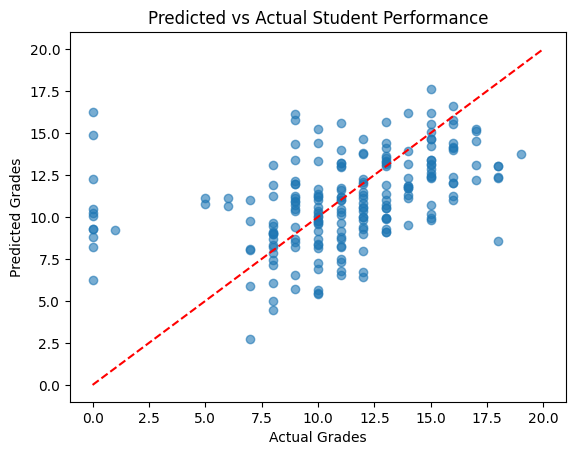

In [290]:
import matplotlib.pyplot as plt

plt.scatter(y_true, y_pred_np, alpha=0.6)
plt.xlabel("Actual Grades")
plt.ylabel("Predicted Grades")
plt.title("Predicted vs Actual Student Performance")
plt.plot([0, 20], [0, 20], color="red", linestyle="--") 
plt.show()
